# 04 Visualisation

This notebook visualises the processed datasets generated in the previous stages of the pipeline.

Inputs:
- `customer_spending.parquet`
- `top_categories.parquet`
- `monthly_trends.parquet`
- `customer_segments.parquet`

These datasets were produced in the Spark processing notebook (02) and stored in the processed data folder.

In [32]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["axes.titleweight"] = "bold"

plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

### Load Processed Data

The processed datasets are loaded from the shared data/processed folder.

To ensure portability across environments, the file paths are resolved dynamically based on the current working directory.

In [33]:
# Resolve project root dynamically
BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(BASE_PATH, "data", "processed")

print("Using processed path:", processed_path)

files = [
    "customer_spending.parquet",
    "top_categories.parquet",
    "monthly_trends.parquet",
    "customer_segments.parquet"
]

for f in files:
    print(f, "exists:", os.path.exists(os.path.join(processed_path, f)))

Using processed path: /home/topi/projektit/data_science/big_data/BigData-Ecommerce-Analysis/data/processed
customer_spending.parquet exists: True
top_categories.parquet exists: True
monthly_trends.parquet exists: True
customer_segments.parquet exists: True


In [34]:
customer_spending = pd.read_parquet(os.path.join(processed_path, "customer_spending.parquet"))
top_categories = pd.read_parquet(os.path.join(processed_path, "top_categories.parquet"))
monthly_trends = pd.read_parquet(os.path.join(processed_path, "monthly_trends.parquet"))
customer_segments = pd.read_parquet(os.path.join(processed_path, "customer_segments.parquet"))

### Data Alignment

Some column names are adjusted to match the visualisation logic while keeping the original datasets unchanged.

In [35]:
# Fix column naming mismatches
customer_spending = customer_spending.rename(columns={
    "total_spent": "total_spend",
    "total_orders": "order_count"
})

top_categories = top_categories.rename(columns={
    "product_category_name": "category_name",
    "total_items_sold": "total_orders"
})

### Customer Spending Patterns

This section explores how customers spend across the platform, including:
- distribution of total spending
- number of orders per customer
- relationship between spending and order behaviour

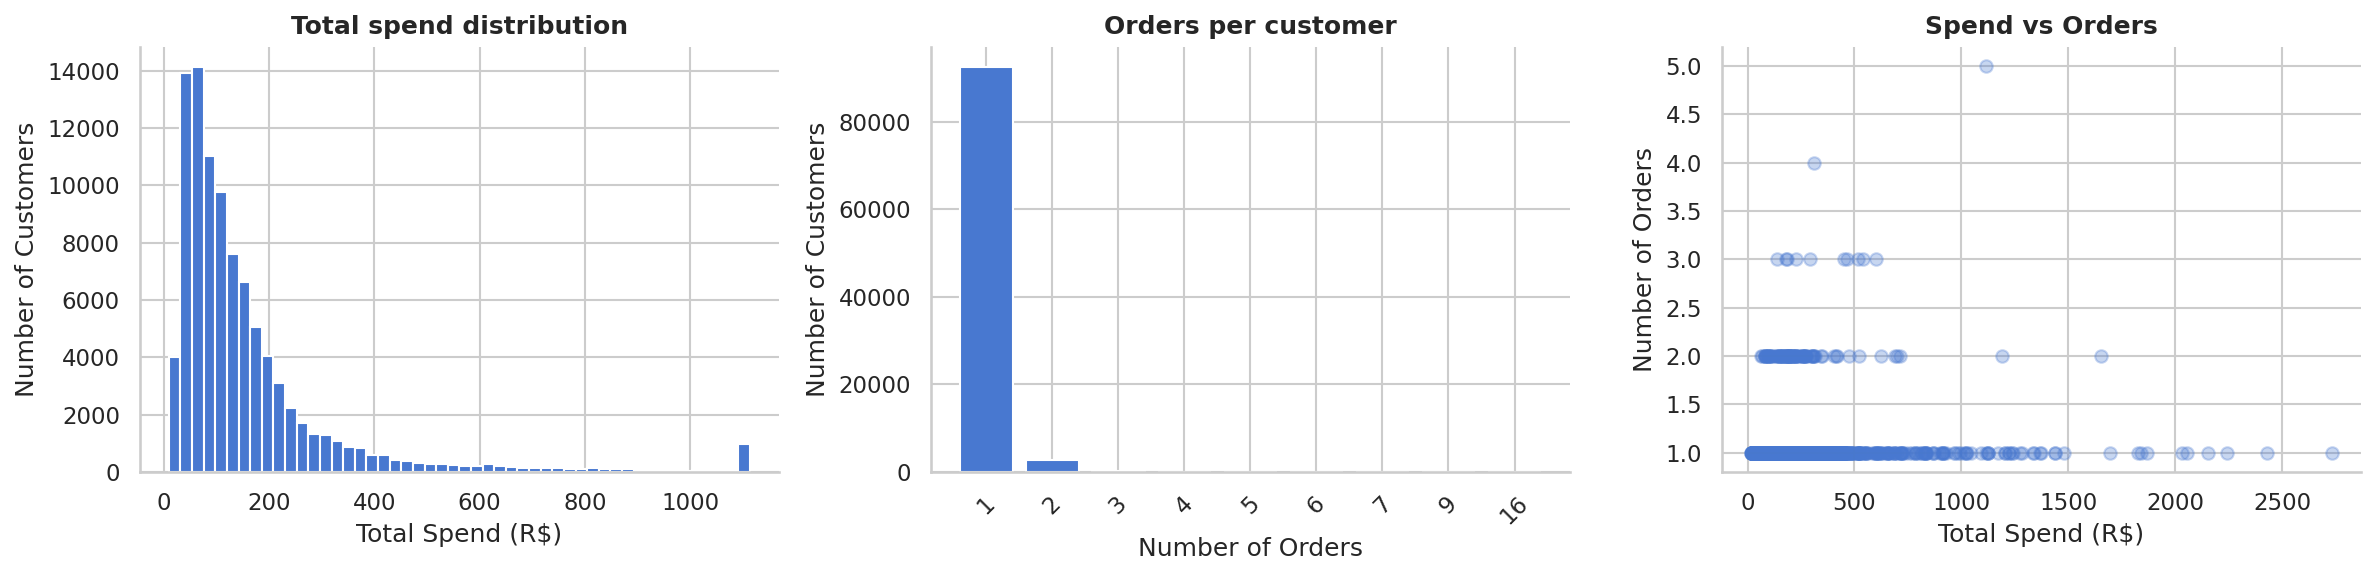

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution
axes[0].hist(
    customer_spending["total_spend"].clip(
        upper=customer_spending["total_spend"].quantile(0.99)
    ),
    bins=50
)
axes[0].set_title("Total spend distribution")
axes[0].set_xlabel("Total Spend (R$)")
axes[0].set_ylabel("Number of Customers")

# Orders per customer
order_counts = customer_spending["order_count"].value_counts().sort_index()
axes[1].bar(order_counts.index.astype(str), order_counts.values)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title("Orders per customer")
axes[1].set_xlabel("Number of Orders")
axes[1].set_ylabel("Number of Customers")

# Scatter
sample = customer_spending.sample(min(3000, len(customer_spending)), random_state=42)
axes[2].scatter(
    sample["total_spend"],
    sample["order_count"],
    alpha=0.3
)
axes[2].set_title("Spend vs Orders")
axes[2].set_xlabel("Total Spend (R$)")
axes[2].set_ylabel("Number of Orders")

plt.tight_layout()
plt.show()

### Top Categories Performance

This section highlights the best-performing product categories based on:
- total order volume
- total revenue

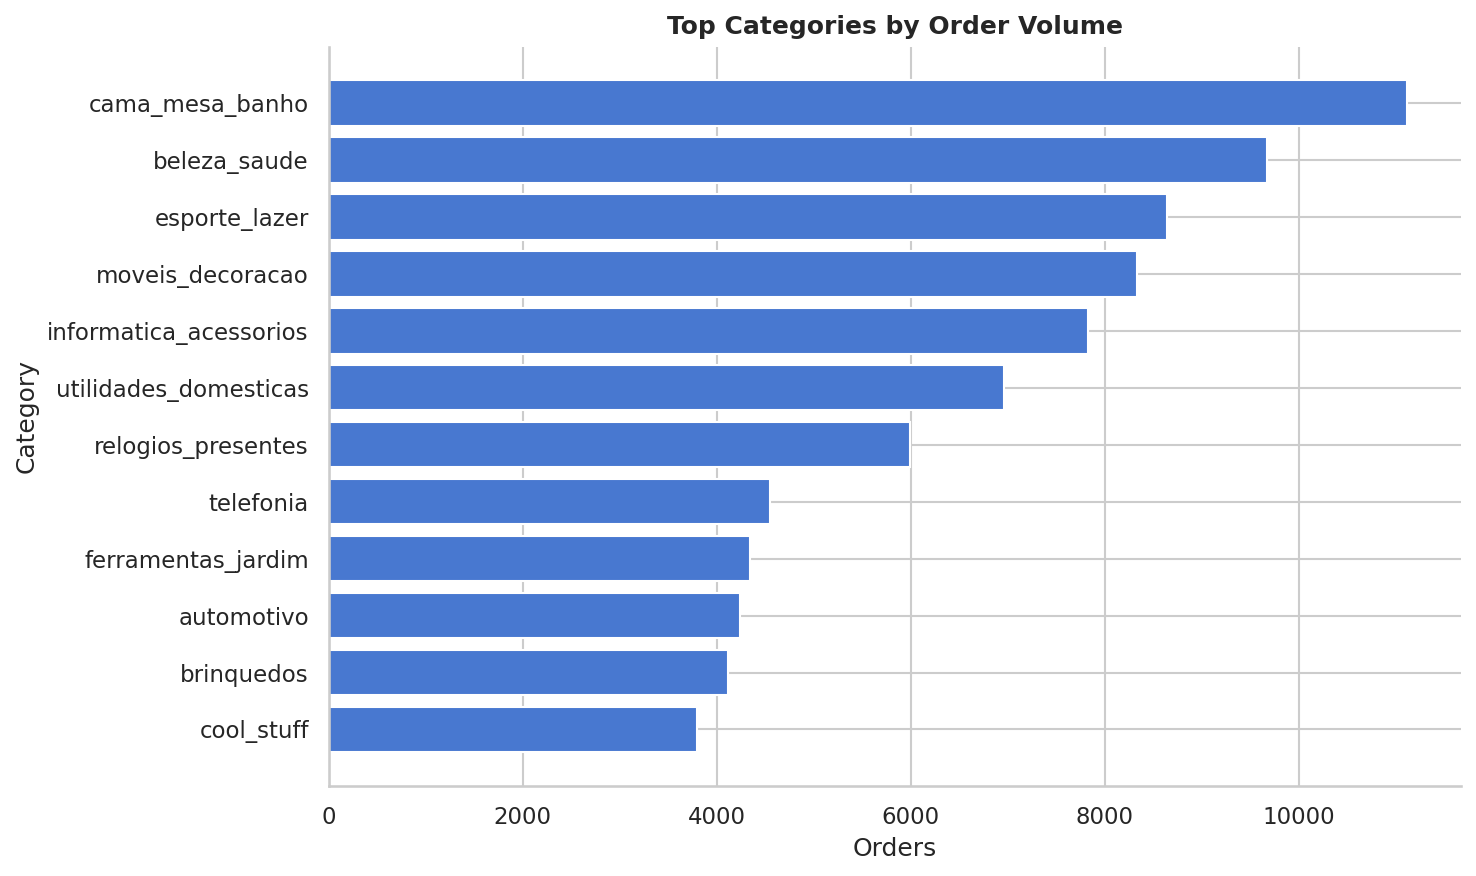

In [37]:
top_n = top_categories.nlargest(12, "total_orders").sort_values("total_orders")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_n["category_name"], top_n["total_orders"])
ax.set_title("Top Categories by Order Volume")
ax.set_xlabel("Orders")
ax.set_ylabel("Category")

plt.tight_layout()
plt.show()

### Monthly Trends

This section examines how order volume and revenue evolve over time.

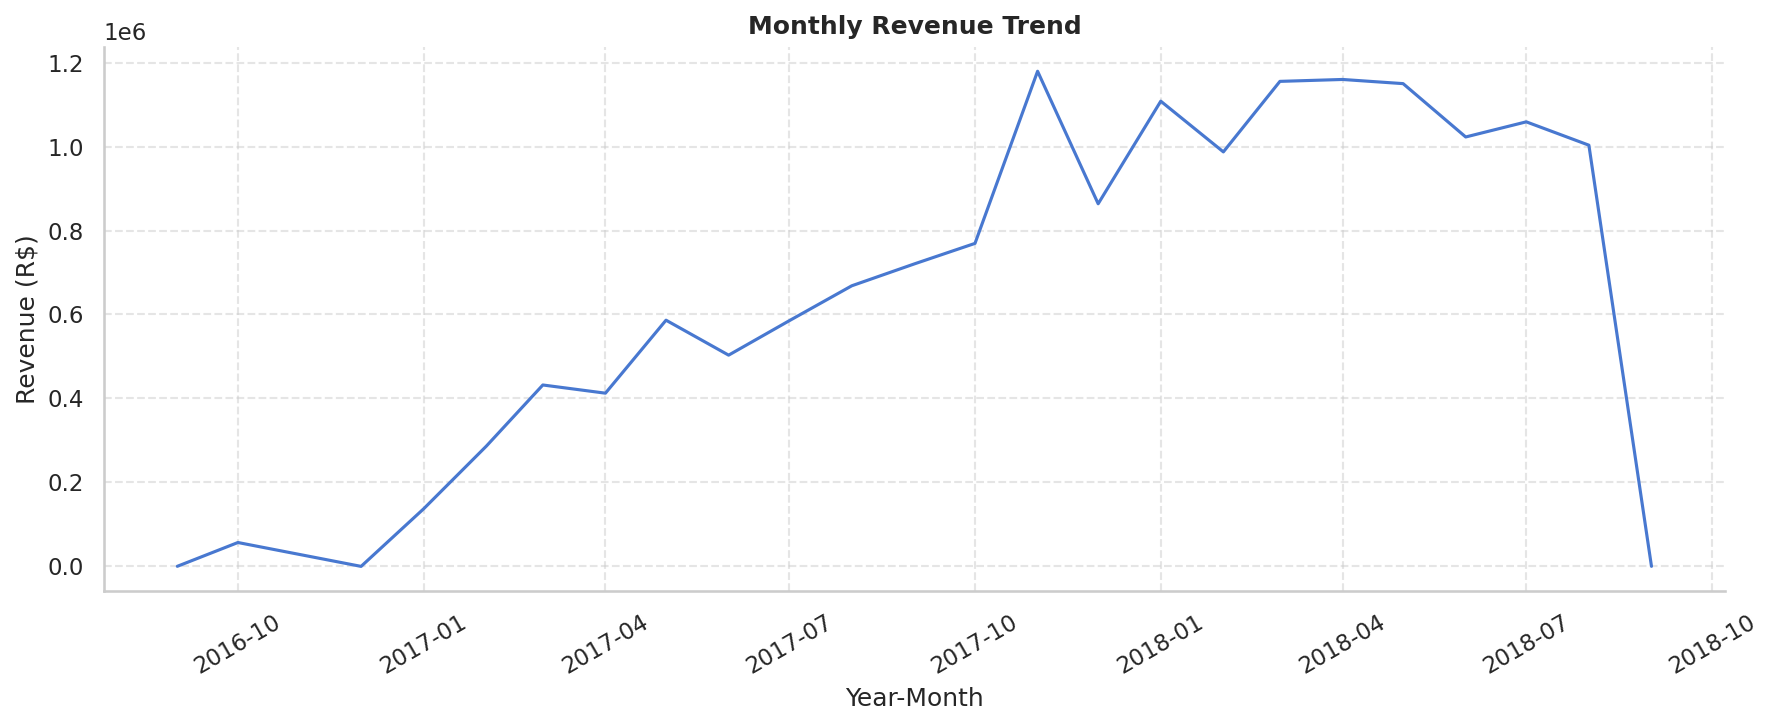

In [38]:
monthly_trends["year_month"] = pd.to_datetime(
    monthly_trends["year"].astype(str) + "-" + monthly_trends["month"].astype(str)
)

monthly_trends = monthly_trends.sort_values("year_month")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_trends["year_month"], monthly_trends["monthly_revenue"])
ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Revenue (R$)")
ax.grid(True, linestyle="--", alpha=0.5)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Customer Segmentation

Customers are grouped into segments based on their total spending. This section visualises the distribution of customers across these segments.

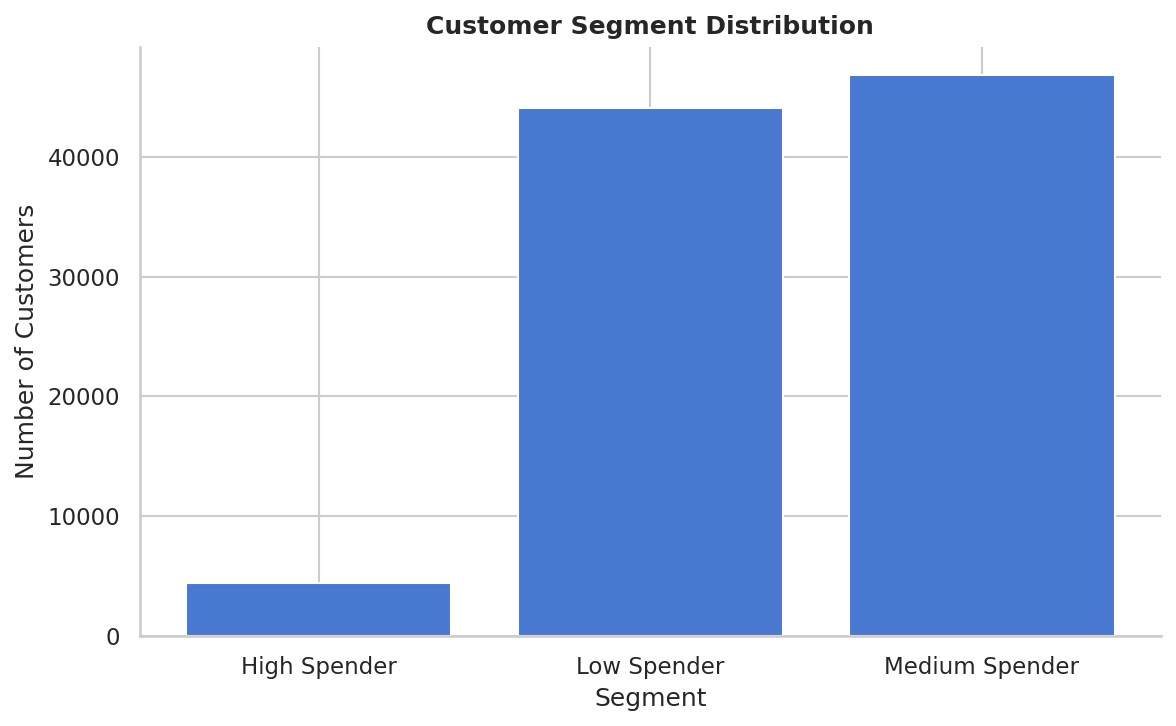

In [39]:
customer_segments = (
    customer_segments
    .groupby("segment")
    .agg(
        customer_count=("customer_unique_id", "count"),
        avg_spend=("total_spent", "mean")
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(customer_segments["segment"], customer_segments["customer_count"])
ax.set_title("Customer Segment Distribution")
ax.set_xlabel("Segment")
ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()